In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
recipes_df = pd.read_csv("./data/recipes.csv")

def getmeals(recipes_df):
    meals = {}
    for _, row in recipes_df.iterrows():
       meals.update({ 
          row["Name"]:(
          row["type"],
          row["Category"],
          row["total_price"],
          row["provided_calories"]
       )})
    return meals

def gettransitionModel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        name = row["Name"]

        if meal_type not in result:
            result[meal_type] = []

        result[meal_type].append(name)

    return result

def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

class GAProblem:
    def __init__(self, recipes_df, total_price, tdee):
        self.meals = getmeals(recipes_df)
        self.size = 90
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = gettransitionModel(recipes_df)
    
    def get_total_cost(self, state):
        total_cost = 0
        for i in range(len(state)):
           breakfast_cost =  self.meals[state[i][0]][2]
           lunch_cost = self.meals[state[i][1]][2]
           dinner_cost  = self.meals[state[i][2]][2]
           day_cost = breakfast_cost+lunch_cost+dinner_cost
           total_cost += day_cost
        return total_cost
    
    def get_total_cal(self,state):
        day_calories = []
        for day in state:
            day_cal = (
            self.meals[day[0]][3] +
            self.meals[day[1]][3] +
            self.meals[day[2]][3]
        )
            if day_cal > self.tdee * 1.1 or day_cal < self.tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
   
    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        cost_penalty = max(0, ((total_cost - self.total_price) / total_cost))
        lower_bound = 0.9 * self.tdee
        upper_bound = 1.1 * self.tdee

        bad_days = 0
        for day in state:
            day_calories = (
                self.meals[day[0]][3] +
                self.meals[day[1]][3] +
                self.meals[day[2]][3]
            )
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += 1
        nutrition_penalty = bad_days / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.4 * cost_penalty +
            0.45 * nutrition_penalty +
            0.15 * diversity_penalty
        )
        return fitness
    def generate_random_state(self):
         return [(random.choice(self.transitionmodel['Breakfast']),
                  random.choice(self.transitionmodel['Lunch']),
                  random.choice(self.transitionmodel['Dinner']))
                    for _ in range(30)]
def crossover_and_mutation(population,problem):
       childs = []
       for i in range(len(population)):
         for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(problem.transitionmodel['Lunch'])
            random_lunch_b = random.choice(problem.transitionmodel['Lunch'])
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
       return childs


def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(100):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:25]
    # step 2 and 3 crossover and mutation
    for _ in range(1000):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:25]
        for state, fitness in population:
            if fitness == 0:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

In [3]:
g = GAProblem(recipes_df,15000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Banana Protein Smoothie', 'Tchicha', 'Chicken Lentil Spinach Dinner'), ('Algerian Mint Tomato Salad', 'Tajine Zitoun', 'Tuna Vegetable Couscous Dinner'), ('Strawberry Yogurt Almond Cup', 'Mderbel', 'Tuna Pasta'), ('Carrot Raisin Yogurt Bowl', 'Couscous Tfaya', 'Daurade Zucchini Olive Dinner'), ('Carrot Raisin Yogurt Bowl', 'Chickpea Chicken Bowl', 'Beef Rice Bowl'), ('Baghrir', 'Doubara', 'Merlan Lemon Olive Plate'), ('Egg White Veggie Wrap', 'Chicken Olive Salad', 'Couscous Shrimp Dinner'), ('Chicken Egg Breakfast Bowl', 'Rice with Peas and Carrots', 'Stuffed Pepper Rice'), ('Cucumber Olive Egg Salad', 'Shrimp Green Bean Rice', 'Hchaichi'), ('Harissa Sardine Egg Plate', 'Rice with Peas and Carrots', 'Chorba Frik Style Chicken'), ('Tomato Pepper Omelette', 'Shrimp Green Bean Rice', 'Chicken Harira Style Bowl'), ('Egg Spinach Scramble', 'Couscous Tfaya', 'Garlic Chicken Spinach'), ('Semolina Milk Honey Bowl', 'Shrimp Avocado Salad', 'Osbane'), ('Potato Onion Omelette DZ', 'Mderbel', 

In [4]:
g = GAProblem(recipes_df,20000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(f"total cost is : {g.get_total_cost(solution)}")
print(f"total calories are : {g.get_total_cal(solution)}")

[('Orange Date Yogurt Bowl', 'Lentil Vegetable Soup', 'Osbane'), ('Orange Date Yogurt Bowl', 'Chicken Cauliflower Rice Bowl', 'Mutton Vegetable Stew'), ('Beet Yogurt Breakfast Plate', 'Beef Spinach Bowl', 'Chickpea Spinach Rice'), ('Carrot Raisin Yogurt Bowl', 'Tajine Zitoun', 'Beef Mushroom Pasta'), ('Turkey Egg Breakfast Bowl', 'Couscous Merlan Mint', 'Chicken Pepper Olive Pan'), ('Sardine Breakfast Plate', 'Garlic Shrimp Bowl', 'Rechta'), ('Chickpea Egg Garlic Bowl', 'Rice & Egg Bowl', 'Marka Hamra'), ('Spinach Cheese Egg Scramble', 'Lentil Vegetable Soup', 'Couscous Shrimp Dinner'), ('Egg Broccoli Scramble', 'Couscous with Vegetables', 'Eggplant Tomato Skillet'), ('Yogurt Fig Honey Bowl', 'Chicken Cauliflower Rice Bowl', 'Chicken Cauliflower Dinner'), ('Orange Date Yogurt Bowl', 'Mutton Chickpea Stew Bowl', 'Dolma'), ('Yogurt Fig Honey Bowl', 'Beef Lettuce Bowl', 'Vegetable Couscous'), ('Egg Oat Protein Pancakes', 'Loubia Tomato Bowl', 'Rechta-Style Chicken Bowl'), ('Cucumber Olive

[('Spinach Olive Omelette', 'Chorba Hamra', 'Hchaichi'), ('Oat Banana Pancake Bowl', 'Chickpea Tomato Stew', 'Vegetable Rice Bowl'), ('Semolina Milk Honey Bowl', 'Mutton Potato Onion Plate', 'Couscous Seffa'), ('Orange Date Yogurt Bowl', 'Chorba Hamra', 'Rechta-Style Chicken Bowl'), ('Lentil Egg Breakfast Bowl', 'Mutton Potato Onion Plate', 'Chicken Lentil Spinach Dinner'), ('322 Bowl', 'Shrimp Avocado Salad', 'Couscous Daurade Dinner'), ('Bourek', 'Spinach Lentil Bowl', 'Sardine Rice Coriander Dinner'), ('Protein Yogurt Crunch', 'Spinach Lentil Bowl', 'Chorba Lentil Lamb'), ('Potato Onion Omelette DZ', 'Tuna Chickpea Mint Salad', 'Tuna Pasta'), ('Egg Broccoli Scramble', 'Chicken Harissa Rice Bowl', 'Green Bean Rice Bowl'), ('Strawberry Yogurt Almond Cup', 'Tuna Rice Olive Bowl', 'Sardine Rice Coriander Dinner'), ('Orange Date Yogurt Bowl', 'Tuna Chickpea Mint Salad', 'Zucchini Tomato Couscous'), ('Banana Peanut Protein Smoothie', 'Spinach Lentil Bowl', 'Green Bean Rice Bowl'), ('Coffe

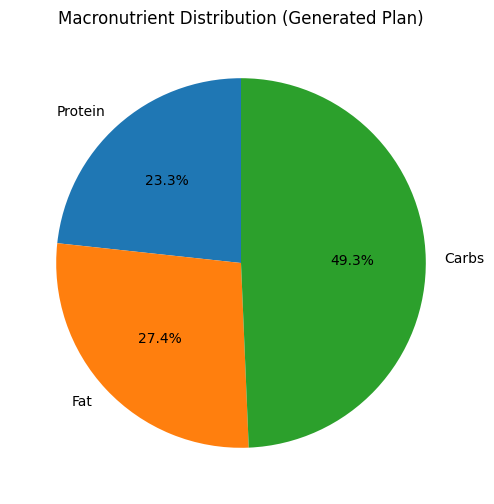

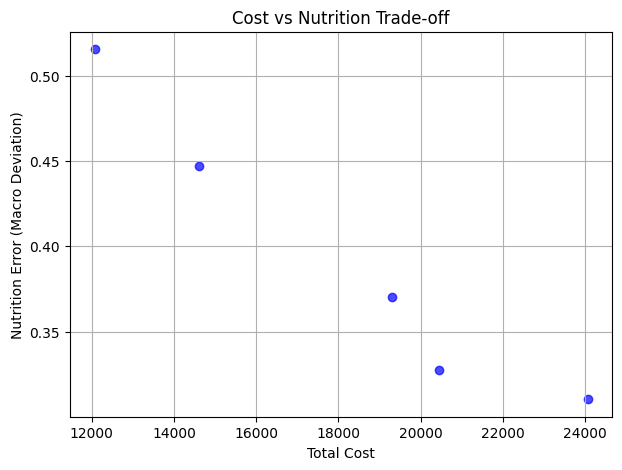

In [5]:

def get_meals_details(recipes_df):
    meals = {}
    for _, row in recipes_df.iterrows():
       meals.update({ 
          row["Name"]:(
          row["provided_calories"],
          row["provided_protein"],
          row["provided_fat"],
          row["provided_carbs"]
       )})
    return meals

def get_macro_nutrition(meals,state):
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
            total_cal += meals[day[0]][0] + meals[day[1]][0] +meals[day[2]][0]
            protein_v += meals[day[0]][1] + meals[day[1]][1] +meals[day[2]][1]
            fat_v += meals[day[0]][2] + meals[day[1]][2] +meals[day[2]][2]
            carbs_v += meals[day[0]][3] + meals[day[1]][3] +meals[day[2]][3]
    return [(protein_v*4)/total_cal,(fat_v*9)/total_cal,(carbs_v*4)/total_cal]

def macro_error(meals,state):
    macros = get_macro_nutrition(meals,state)

    target = [0.4, 0.3, 0.3]  # example

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 10000
     for _ in range(5):  # 30 different solution
        g = GAProblem(recipes_df,i,2000)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 5000 
        costs.append(cost)
        errors.append(error)
     return costs,errors

g = GAProblem(recipes_df,20000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(f"total cost is : {g.get_total_cost(solution)}")
print(f"total calories are : {g.get_total_cal(solution)}")

meals_details = get_meals_details(recipes_df)
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Generated Plan)')
plt.show()

x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()
